In [10]:
import pandas as pd
import os
import sys

# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_processor import ForecastTransformer
from src.database_utils import CFSDatabase
from src.data_loader import DataLoader
from src.plotting import plot_forecast, plot_forecast_interactive
from src.utilities import get_first_forecast_month

In [11]:
start_date = get_first_forecast_month()

First forecast month: 2025-11


In [ ]:
prob = DataLoader().lake_probabilities("/Users/ljob/Desktop/cnbs-predictor/data/probabilities/", units="mm")
def align_prob_with_start_date(merged_df, start_date):
    """
    Align merged_df months to a given start date.

    Parameters
    ----------
    merged_df : pd.DataFrame
        Output of load_lake_probabilities(), with 'month' and 'month_num'.
    start_date_str : str
        Start date in "YYYY-MM" format (e.g., "2025-10").

    Returns
    -------
    pd.DataFrame
        merged_df with datetime index starting from start_date_str.
    """
    # Month mapping
    month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    merged_df["month_num"] = merged_df["month"].apply(lambda x: month_order.index(x) + 1)
    
    # Parse the start year and month
    start_year, start_month = map(int, start_date.split("-"))

    def compute_year(month_num):
        # months >= start_month are in start_year, months < start_month are next year
        return start_year if month_num >= start_month else start_year + 1

    merged_df["year"] = merged_df["month_num"].apply(compute_year)

    # Build datetime index
    merged_df["date"] = pd.to_datetime({
        "year": merged_df["year"],
        "month": merged_df["month_num"],
        "day": 1
    })

    merged_df = merged_df.set_index("date").sort_index()
    merged_df = merged_df.drop(columns=["month_num","year"])
    return merged_df

prob_aligned = align_prob_with_start_date(prob, start_date)

In [14]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast.db'
cnbs_table = 'cnbs_forecast'

In [15]:
# Load CNBS predictions
data = CFSDatabase(cnbs_database, cnbs_table).load()

In [16]:
df_filtered = ForecastTransformer(data).filter(get_first_forecast_month())

First forecast month: 2025-11


**Plotting the 12-Month Great Lakes Net Basin Supply (NBS) Forecasts**

This cell generates a **4×4 grid of subplots** visualizing precipitation, evaporation, runoff, and total NBS forecasts for each of the four Great Lakes basins (Superior, Michigan-Huron, Erie, Ontario).  

### Key Steps:

1. **Color Assignment**  
   - Assigns a distinct color to each model using a predefined color list (`custom_colors`).  
   - Raises an error if the number of models exceeds available colors.

2. **Data Setup**  
   - Defines the plotting order of 16 forecast variables (4 components × 4 lakes).  
   - Creates subplot grid (`fig, axs`) for visual arrangement.  
   - Tracks separate y-axis ranges for precipitation, evaporation, and runoff (columns 0–2) versus total NBS (column 3).

3. **Plotting for Each Variable**  
   - For each component/lake combination:
     - Computes **95% confidence intervals** using the 2.5th and 97.5th percentiles.
     - Plots the mean forecast for each model with unique colors and markers.
     - Shades the 95% confidence interval region in gray (`fill_between`).
     - Adds horizontal zero reference lines, gridlines, and shared y-ticks.
     - Dynamically adjusts y-axis limits so that subplots share consistent scaling.

4. **Formatting**  
   - Adds component titles across the top row (Precipitation, Evaporation, Runoff, Total NBS).
   - Labels y-axes by lake name for the first column.
   - Formats x-axis dates (`%m-%Y`) for the bottom row, rotating labels for readability.

5. **Final Layout & Output**  
   - Synchronizes y-axis limits across similar variable types.
   - Sets the plot’s main title: *"Great Lakes 12-Month CNBS [mm] Forecast"*.
   - Adds a legend to the top-right subplot.
   - Saves the figure as `CNBS_forecasts.png` in the forecast output directory.
   - Displays the final figure.

**Purpose:**  
This visualization provides a **multi-model ensemble view** of the Great Lakes’ hydrological forecast components over the next 12 months, allowing easy comparison of models, seasonal cycles, and uncertainty ranges.

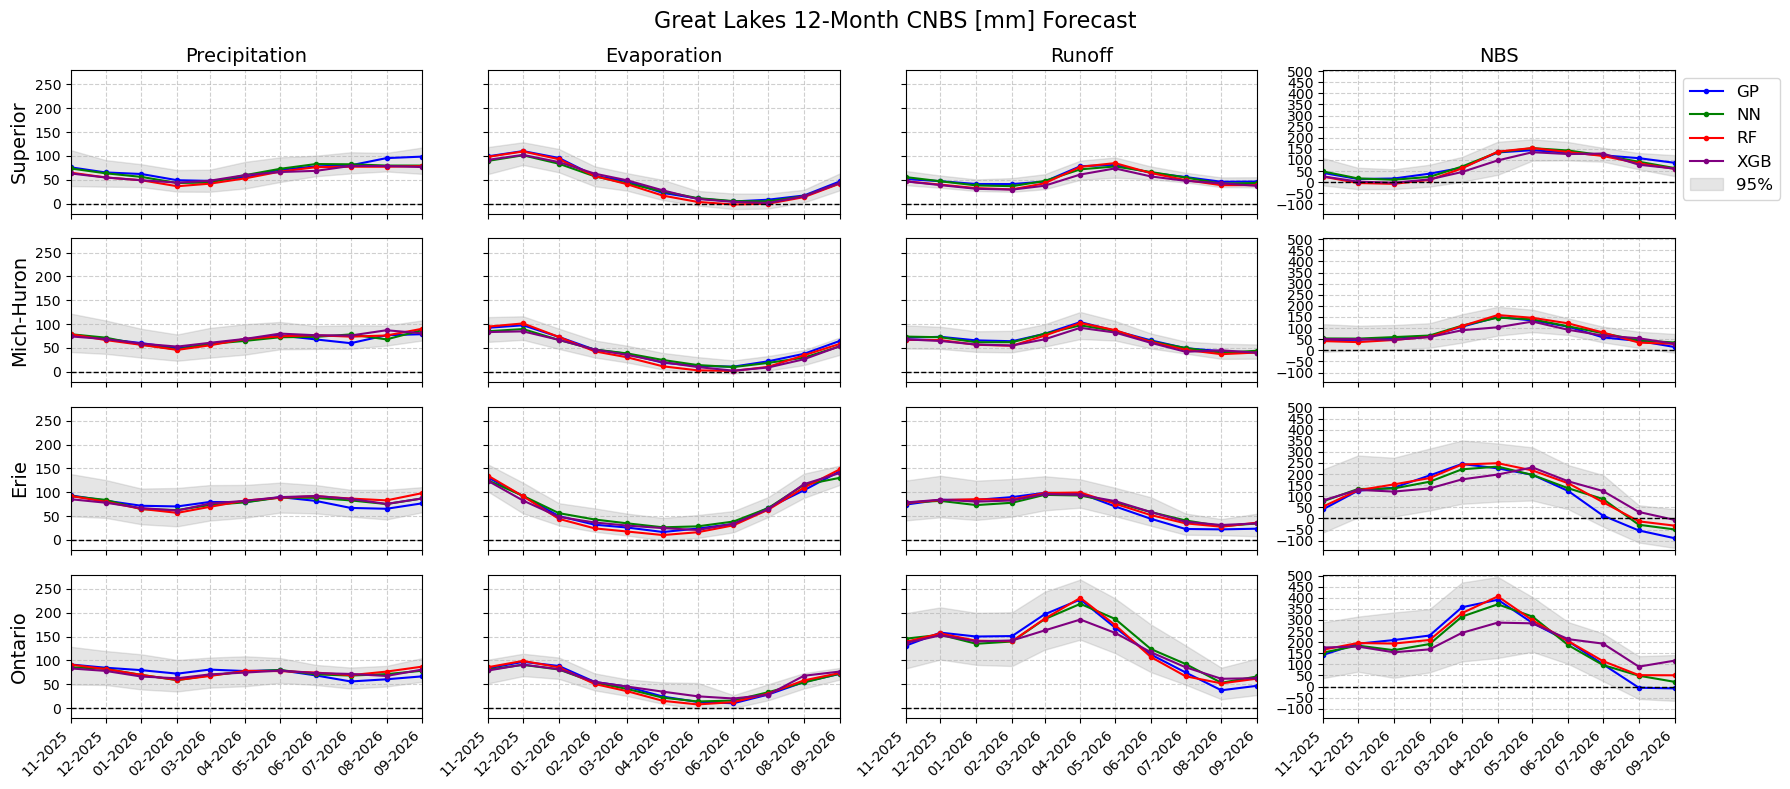

In [17]:
plot_forecast(df_filtered)

**Interactive 4×4 Grid of Great Lakes 12-Month NBS Forecasts**

This section uses **Plotly** to create a fully interactive **4×4 subplot grid** that visualizes the mean forecasts and uncertainty ranges for precipitation, evaporation, runoff, and total CNBS across the four Great Lakes basins.

In [18]:
plot_forecast_interactive(df_filtered)

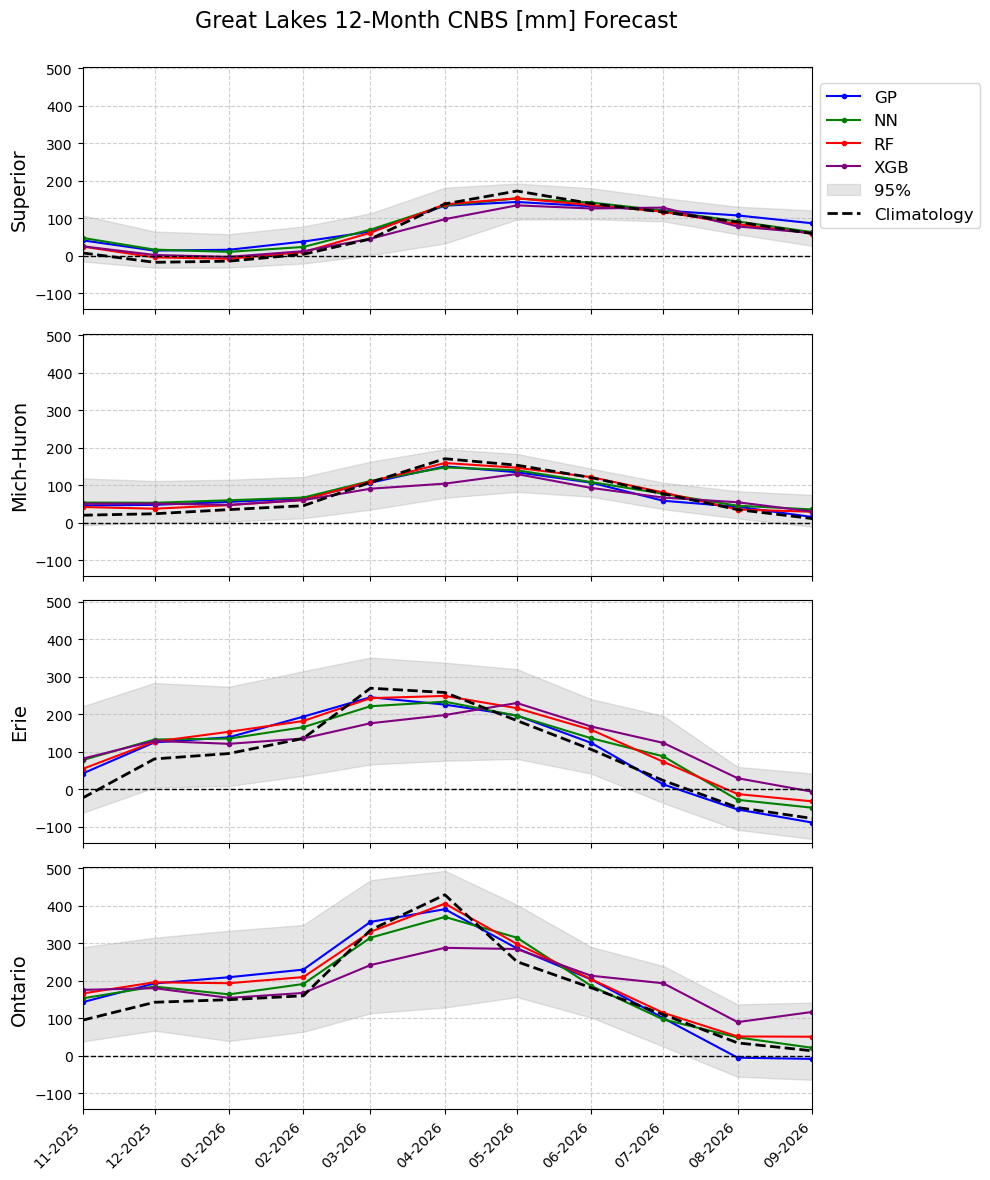

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", message="This axis already has a converter set")

df = df_filtered.copy()
df["date"] = pd.to_datetime(df["forecast_month"], format="%Y-%m")

# Unique models
models_info = df["model"].unique().tolist()

# Colors
custom_colors = ['blue', 'green', 'red', 'purple', 'orange',
                 'brown', 'pink', 'olive', 'cyan', 'magenta']
if len(models_info) > len(custom_colors):
    raise ValueError(
        f"Number of models ({len(models_info)}) exceeds available colors "
        f"({len(custom_colors)}). Add more colors."
    )
model_colors = {model: custom_colors[i] for i, model in enumerate(models_info)}

# Lakes and components
lakes = ["superior", "michigan-huron", "erie", "ontario"]
components = ["nbs"]

fig, axs = plt.subplots(len(lakes), len(components), figsize=(10, 12), squeeze=False)
shared_y_min, shared_y_max = float('inf'), float('-inf')
col4_y_min, col4_y_max = float('inf'), float('-inf')

for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        lake_df = df[df["lake"] == lake]

        # Confidence intervals
        lower = lake_df.groupby("forecast_month")[comp].quantile(0.025).reset_index()
        upper = lake_df.groupby("forecast_month")[comp].quantile(0.975).reset_index()
        lower["date"] = pd.to_datetime(lower["forecast_month"], format="%Y-%m")
        upper["date"] = pd.to_datetime(upper["forecast_month"], format="%Y-%m")

        # Plot each model
        for model_name in models_info:
            model_mean = lake_df[lake_df["model"] == model_name]
            mean_df = model_mean.groupby("forecast_month").mean(numeric_only=True).reset_index()
            mean_df["date"] = pd.to_datetime(mean_df["forecast_month"], format="%Y-%m")

            ax.plot(mean_df["date"], mean_df[comp], marker='o', markersize=3,
                    color=model_colors[model_name], label=model_name)

        ax.fill_between(lower["date"], lower[comp], upper[comp],
                        color='gray', alpha=0.2, label='95%')
        
        prob_aligned[lake].plot(ax=ax, label=f"Climatology", color='black', linestyle='--', linewidth=2)

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))
        ax.set_xlabel("")

        # Track y-limits
        current_y_min = lower[comp].min()
        current_y_max = upper[comp].max()
        if col < 3:
            shared_y_min = min(shared_y_min, current_y_min)
            shared_y_max = max(shared_y_max, current_y_max)
        else:
            col4_y_min = min(col4_y_min, current_y_min)
            col4_y_max = max(col4_y_max, current_y_max)

        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(["Superior", "Mich-Huron", "Erie", "Ontario"][row], fontsize=14)
        elif col == 3:
            ax.set_ylabel("")
        else:
            ax.set_yticklabels([])

# Apply y-axis limits
for row_idx in range(len(lakes)):
    for col_idx in range(len(components)):
        if col_idx < 3:
            axs[row_idx, col_idx].set_ylim(shared_y_min-10, shared_y_max+10)
        else:
            axs[row_idx, col_idx].set_ylim(col4_y_min-10, col4_y_max+10)
        axs[row_idx, col_idx].set_xlim(df["date"].min(), df["date"].max())

fig.suptitle("Great Lakes 12-Month CNBS [mm] Forecast", fontsize=16, x=0.2, ha='left')
axs[0, 0].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

plt.tight_layout()
plt.show()

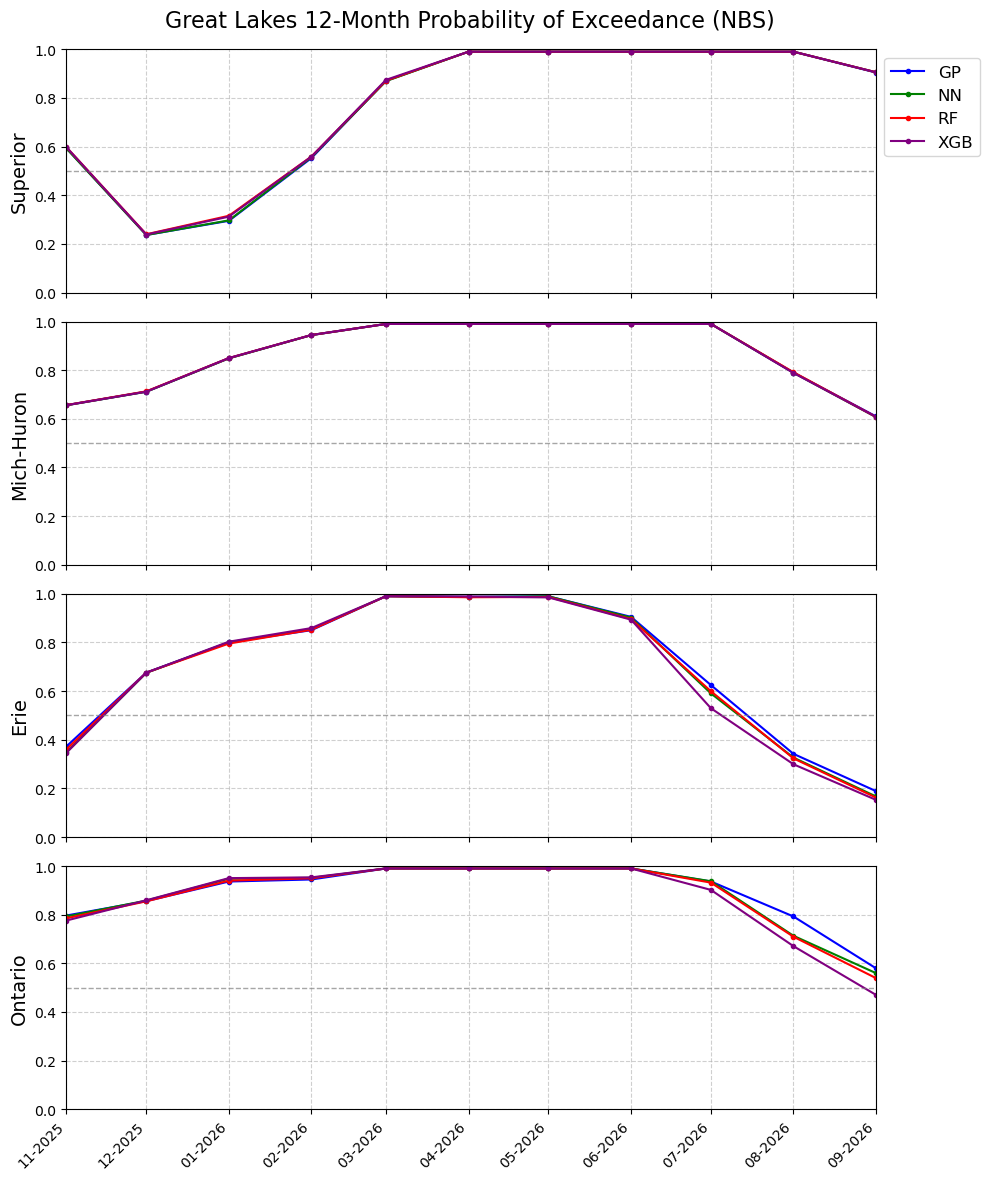

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message="This axis already has a converter set")

# --- Input: combined_df with forecast_month, lake, model, nbs, etc. ---
df = combined_df.copy()
df["date"] = pd.to_datetime(df["forecast_month"], format="%Y-%m")

# --- Lake to file code mapping ---
lake_code_map = {
    "superior": "SUP",
    "michigan-huron": "MIH",
    "erie": "ERI",
    "ontario": "ONT",
}

# --- Colors for models ---
models_info = df["model"].unique().tolist()
custom_colors = ['blue', 'green', 'red', 'purple', 'orange',
                 'brown', 'pink', 'olive', 'cyan', 'magenta']
if len(models_info) > len(custom_colors):
    raise ValueError(
        f"Number of models ({len(models_info)}) exceeds available colors "
        f"({len(custom_colors)}). Add more colors."
    )
model_colors = {model: custom_colors[i] for i, model in enumerate(models_info)}

# --- Lakes ---
lakes = ["superior", "michigan-huron", "erie", "ontario"]

# --- Month map for PoE lookup ---
MONTH_MAP = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

def get_poe(value, month_name, poe_df):
    """Interpolate the probability of exceedance for the given month."""
    if month_name not in poe_df.columns:
        return np.nan
    x = poe_df[month_name].values
    y = poe_df["Probability Of Exceedance"].values
    if len(x) == 0 or len(y) == 0:
        return np.nan
    if value <= x.min():
        return y.max()
    if value >= x.max():
        return y.min()
    return np.interp(value, x, y)

# --- Folder where PoE CSVs live ---
poe_folder = "/Users/ljob/Desktop/cnbs-predictor/data/probabilities"

# --- Initialize figure ---
fig, axs = plt.subplots(len(lakes), 1, figsize=(10, 12), squeeze=False)
fig.suptitle("Great Lakes 12-Month Probability of Exceedance (NBS)", fontsize=16, x=0.17, ha='left')

shared_y_min, shared_y_max = 0, 1  # PoE is always between 0–1

# --- Loop over lakes ---
for row, lake in enumerate(lakes):
    ax = axs[row, 0]
    lake_df = df[df["lake"] == lake]
    lake_code = lake_code_map.get(lake.lower())
    if not lake_code:
        ax.text(0.5, 0.5, f"No mapping for {lake}", ha='center', va='center')
        continue

    poe_file = os.path.join(poe_folder, f"{lake_code}.probs.csv")
    if not os.path.exists(poe_file):
        ax.text(0.5, 0.5, f"Missing PoE file: {lake_code}", ha='center', va='center')
        continue

    poe_df = pd.read_csv(poe_file, skiprows=7)
    poe_df["Probability Of Exceedance"] = poe_df["Probability Of Exceedance"].astype(float)

    # Plot each model
    for model_name in models_info:
        model_mean = lake_df[lake_df["model"] == model_name]
        mean_df = model_mean.groupby("forecast_month").mean(numeric_only=True).reset_index()
        mean_df["date"] = pd.to_datetime(mean_df["forecast_month"], format="%Y-%m")

        # Compute PoE for each month
        poes = []
        for _, row_data in mean_df.iterrows():
            month_num = row_data["date"].month
            month_name = MONTH_MAP[month_num]
            poe = get_poe(row_data["nbs"], month_name, poe_df)
            poes.append(poe)
        mean_df["PoE"] = poes

        # Plot line
        ax.plot(mean_df["date"], mean_df["PoE"], marker='o', markersize=3,
                color=model_colors[model_name], label=model_name)

    # Styling
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(0, 1)
    ax.set_xlim(df["date"].min(), df["date"].max())

    # Format x-axis
    if row == len(lakes) - 1:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
        ax.tick_params(axis='x', rotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')
    else:
        ax.set_xticklabels([])

    # Labels
    ax.set_ylabel(["Superior", "Mich-Huron", "Erie", "Ontario"][row], fontsize=14)

# Legend and layout
axs[0, 0].legend(loc='lower left', bbox_to_anchor=(1, 0.525), fontsize=12)
plt.tight_layout()
plt.show()
